# Semantic Similarity-Based Dynamic Ground Truth Generation

## Objective

Traditional approaches compute the ground-truth score by taking the simple average of the scores assigned by two human annotators.

This notebook proposes a **Semantic Similarity-Based Dynamic Annotator Weighting** method, where the contribution of each annotator is dynamically determined for every resume based on the consistency of annotator scores among semantically similar resumes.

The generated **Dynamic Ground Truth** can be used as the target label for downstream resume ranking and candidate evaluation models.

# Proposed Methodology

The proposed pipeline consists of the following steps:

1. Merge resume attributes into a single textual representation.
2. Generate semantic embeddings using Sentence-BERT.
3. Retrieve semantically similar resumes using cosine similarity.
4. Estimate local annotator consistency using Median Absolute Deviation (MAD).
5. Convert consistency scores into normalized annotator weights.
6. Compute Dynamic Ground Truth using weighted annotator scores.

Ground Truth Formula:

GT = w₁ × Annotator₁ + w₂ × Annotator₂

where

w₁ + w₂ = 1

In [1]:
!pip install -q sentence-transformers

## Step 1: Install Required Libraries

Sentence-BERT is used to generate semantic embeddings of resumes.

In [2]:
# ============================================================
# Cell 1 : Import Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

## Step 2: Import Required Packages

The required libraries are imported for:

- Data manipulation
- Semantic embedding generation
- Nearest neighbour search
- Visualization

In [3]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

## Step 3: Load Resume Dataset

The dataset contains:

- Resume Information
- Annotator-1 Score
- Annotator-2 Score

These two annotator scores will be fused into a Dynamic Ground Truth.

In [4]:
from google.colab import files

uploaded = files.upload()

Saving CareerCorpus.xlsx to CareerCorpus (3).xlsx


In [5]:
df = pd.read_excel("CareerCorpus.xlsx")

df.head()

,ID,Domain,Education,Skills and Achievements,Experience,Job_type,Annotator-1,Annotator-2
0,74552449,Banking,"Master of Science in International Trade, Univ...","Skilled in cash handling, loan operations, fin...",Professional (11/2016–Present)—opened and mana...,Entry-level,0.80,0.88
1,79041971,Banking,"High School Diploma, Federal Way Senior High S...","Strong leadership, team management, and client...",Banking Professional (Aug 2013–Present)—overse...,Mid-level,0.40,0.75
2,77156708,Banking,"Master of Management, Business Management — Co...",NMLS #1796859; business development; project m...,Banking Officer (10/2018–Current)—BSA/AML/OFAC...,Mid-level,0.84,0.97
3,24580361,Banking,"B.S. in Operations Management, University of D...",Microsoft Office (Excel/PowerPoint/Word/Access...,"Associate, Investment Banking Operations (07/2...",Senior-level,0.76,0.97
4,34953092,Banking,"M.S. Computer Engineering, University of Misso...","C/C++, Python, MATLAB, SQL, R, LUA, VBA; ML (s...","Corporate Banking Assistant, Intern (May–Aug 2...",Entry-level,0.76,0.88


## Step 4: Construct Resume Representation

Multiple resume attributes are merged into a single textual representation.

This enables semantic comparison between resumes instead of treating each field independently.

In [6]:
df["Resume_Text"] = (
    df["Education"].fillna("") + " " +
    df["Skills and Achievements"].fillna("") + " " +
    df["Experience"].fillna("") + " " +
    df["Domain"].fillna("") + " " +
    df["Job_type"].fillna("")
)

## Step 5: Semantic Embedding Generation

Each resume is transformed into a dense semantic vector using the pretrained Sentence-BERT model.

Unlike TF-IDF, Sentence-BERT captures contextual meaning rather than simple keyword frequency.

In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

resume_embeddings = model.encode(
    df["Resume_Text"].tolist(),
    show_progress_bar=True
)

print(resume_embeddings.shape)

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

(302, 384)


## Step 6: Retrieve Semantic Neighbours

For every resume, the ten most semantically similar resumes are identified using cosine similarity.

These neighbours provide local contextual information for estimating annotator reliability.

In [8]:
knn = NearestNeighbors(
    n_neighbors=11,
    metric="cosine"
)

knn.fit(resume_embeddings)

distances, indices = knn.kneighbors(resume_embeddings)

## Step 7: Dynamic Annotator Weight Estimation

Annotator consistency is estimated using the Median Absolute Deviation (MAD) within the semantic neighbourhood.

A lower MAD indicates greater consistency and therefore receives a higher weight.

The weights are normalized so that:

w₁ + w₂ = 1

In [9]:
weights1 = []
weights2 = []

a1 = df["Annotator-1"].values
a2 = df["Annotator-2"].values

epsilon = 1e-8

for i in range(len(df)):

    neighbors = indices[i][1:]

    neigh_a1 = a1[neighbors]
    neigh_a2 = a2[neighbors]

    med1 = np.median(neigh_a1)
    med2 = np.median(neigh_a2)

    mad1 = np.median(np.abs(neigh_a1 - med1))
    mad2 = np.median(np.abs(neigh_a2 - med2))

    consistency1 = 1 / (mad1 + epsilon)
    consistency2 = 1 / (mad2 + epsilon)

    total = consistency1 + consistency2

    weights1.append(consistency1 / total)
    weights2.append(consistency2 / total)

## Step 8: Generate Dynamic Ground Truth

The final ground-truth score is computed as a weighted combination of the two annotator scores.

Unlike simple averaging, the weights are dynamically assigned for each resume.

In [10]:
df["Weight_Annotator1"] = weights1
df["Weight_Annotator2"] = weights2

df["Dynamic_GT"] = (
    df["Weight_Annotator1"] * df["Annotator-1"] +
    df["Weight_Annotator2"] * df["Annotator-2"]
)

df.head()

,ID,Domain,Education,Skills and Achievements,Experience,Job_type,Annotator-1,Annotator-2,Resume_Text,Weight_Annotator1,Weight_Annotator2,Dynamic_GT
0,74552449,Banking,"Master of Science in International Trade, Univ...","Skilled in cash handling, loan operations, fin...",Professional (11/2016–Present)—opened and mana...,Entry-level,0.80,0.88,"Master of Science in International Trade, Univ...",0.235294,0.764706,0.861176
1,79041971,Banking,"High School Diploma, Federal Way Senior High S...","Strong leadership, team management, and client...",Banking Professional (Aug 2013–Present)—overse...,Mid-level,0.40,0.75,"High School Diploma, Federal Way Senior High S...",0.303030,0.696970,0.643939
2,77156708,Banking,"Master of Management, Business Management — Co...",NMLS #1796859; business development; project m...,Banking Officer (10/2018–Current)—BSA/AML/OFAC...,Mid-level,0.84,0.97,"Master of Management, Business Management — Co...",0.277778,0.722222,0.933889
3,24580361,Banking,"B.S. in Operations Management, University of D...",Microsoft Office (Excel/PowerPoint/Word/Access...,"Associate, Investment Banking Operations (07/2...",Senior-level,0.76,0.97,"B.S. in Operations Management, University of D...",0.322581,0.677419,0.902258
4,34953092,Banking,"M.S. Computer Engineering, University of Misso...","C/C++, Python, MATLAB, SQL, R, LUA, VBA; ML (s...","Corporate Banking Assistant, Intern (May–Aug 2...",Entry-level,0.76,0.88,"M.S. Computer Engineering, University of Misso...",0.260870,0.739130,0.848696


## Step 9: Weight Distribution

The histogram illustrates the variation in annotator weights across resumes, demonstrating that the proposed method assigns resume-specific weights rather than fixed values.

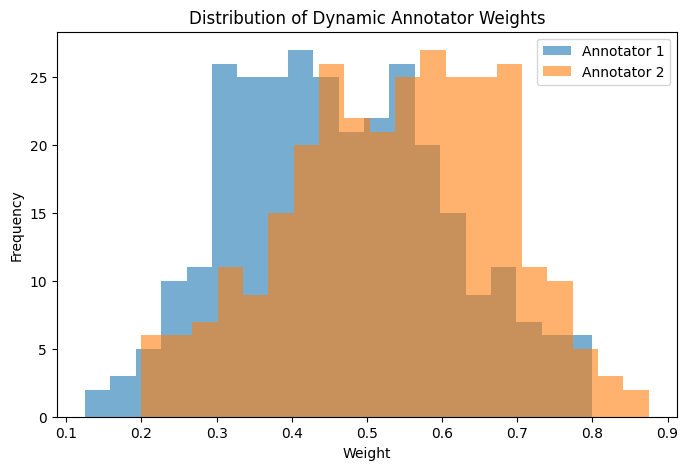

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df["Weight_Annotator1"], bins=20, alpha=0.6, label="Annotator 1")
plt.hist(df["Weight_Annotator2"], bins=20, alpha=0.6, label="Annotator 2")

plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Distribution of Dynamic Annotator Weights")

plt.legend()

plt.show()

## Step 10: Export Dataset

The generated dataset contains:

- Weight_Annotator1
- Weight_Annotator2
- Dynamic_GT

These outputs can now be used as labels for downstream machine learning models and compared against the traditional average-based ground truth.

In [12]:
df.to_csv("CareerCorpus_DynamicGT.csv", index=False)

print("Dynamic Ground Truth Dataset Saved Successfully.")

Dynamic Ground Truth Dataset Saved Successfully.
